In [1]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia
from boulder_statistics.analysis.external_data_encyclopedia import ExternalDataEncyclopedia
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
from typing import Dict
from typing import Callable

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

ed = ExternalDataEncyclopedia(
    external_data_path=Path(r"C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\external_data")
)

In [2]:
refine_plus_export_pool = Path("refine_plus_export_pool")
combined_db_export_pool = Path("combined_db_export_pool")
agg_export_pool = Path("agg_export_pool/pass_00")
pass_00_path: Path = combined_db_export_pool / "pass_00"
pass_01_path: Path = combined_db_export_pool / "pass_01"
pass_02_path: Path = combined_db_export_pool / "pass_02"
pipeline_from_here_needs_running : bool = False

## Fill export pool

In [3]:
refine_plus_export_pool.mkdir(exist_ok=True, parents=True)

In [4]:
from boulder_statistics.refinement_plus.project_facets import ProjectFacets
from boulder_statistics.refinement_plus.bulk_parse_data_maps import BulkParseDataMaps

tir_bpdm = BulkParseDataMaps(
    data_type="TIR",
    cache_file_path=Path(r".cache/data_tir_maps_parse_cache.parquet"),
    data_maps_path=ed.data_tir_maps_path
)

data_tir_maps = tir_bpdm.bulk_parse()


for mission_phase in ["detailed_survey", "recona", "reconb", "reconc"]:

    pf = ProjectFacets(
        mesh_folder=Path(r"C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\external_data\bennu_models"),
        export_pool_folder=refine_plus_export_pool,
        measurement_types_of_interest = tir_bpdm.get_all_measurement_types_of_interest,
        facet_maps=data_tir_maps,
        mission_phase=mission_phase,
        instrument_type='TIR',
        pipeline_from_here_needs_running = pipeline_from_here_needs_running,
        dp=dp
    )

    pf.process_mission_phase()

c:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\.venv\Lib\site-packages\tqdm_joblib\__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [5]:
from boulder_statistics.refinement_plus.bulk_parse_data_maps import BulkParseDataMaps

vnir_bpdm = BulkParseDataMaps(
    data_type="VNIR",
    cache_file_path=Path(r".cache/data_vnir_maps_parse_cache.parquet"),
    data_maps_path=ed.data_vnir_maps_path
)

data_vnir_maps = vnir_bpdm.bulk_parse()

for mission_phase in ["detailed_survey", "recona", "reconb", "reconc"]:

    pf = ProjectFacets(
        mesh_folder=Path(r"C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\external_data\bennu_models"),
        export_pool_folder=refine_plus_export_pool,
        measurement_types_of_interest = vnir_bpdm.get_all_measurement_types_of_interest,
        facet_maps=data_vnir_maps,
        mission_phase=mission_phase,
        instrument_type='VNIR',
        dp=dp,
        pipeline_from_here_needs_running = pipeline_from_here_needs_running
    )

    pf.process_mission_phase()

In [6]:
from boulder_statistics.refinement_plus.qcube_chunk import QCubeChunk
from boulder_statistics.refinement_plus.refinement_chunking import ChunkingTools
from boulder_statistics.refinement_plus.refinement_tools import restrict_by_clipped_sigma_log_space

def handle_mesh(chunk : QCubeChunk) -> np.ndarray:
    areas: np.ndarray = ChunkingTools.extract_chunks(dp.Phi_mesh, chunk, ["area"])[0]
    areas *= 1e6 # Convert to m^2
    areas = restrict_by_clipped_sigma_log_space(areas)

    return areas

area_export_folder: Path = refine_plus_export_pool / "00_add_areas"

if (not area_export_folder.exists()) or pipeline_from_here_needs_running:
    pipeline_from_here_needs_running = True
    
    ChunkingTools.append_by_chunks(
        dp.combined_atlas.select("i", "j", "face"),
        refine_plus_export_pool / "00_add_areas",
        "area",
        handle_mesh,
        chunks = QCubeChunk.generate(depth=2)
    )

## Combine pass 00

In [7]:
import os
from boulder_statistics.refinement_plus.qcube_chunk import QCubeChunk
from boulder_statistics.refinement_plus.refinement_chunking import ChunkingTools

lfs_to_join: list[LazyFrame] = [
    pl.scan_parquet(refine_plus_export_pool / table_name)
    for table_name in os.listdir(refine_plus_export_pool)
] + [
    dp.combined_atlas,
    dp.combined_mask.unique(
    subset=["i", "j", "face"], keep="first" # Sometimes duplicates can occur but are rare
    ).rename({
        "lod_level": "detection_lod_level",
        "lod_code": "detection_lod_code",
        "row_id" : "boulder_id"
    })
]

for lf in lfs_to_join:
    print(lf.collect_schema().names())

if not pass_00_path.exists() or pipeline_from_here_needs_running:
    pass_00_path.mkdir(exist_ok=True, parents=True)
    pipeline_from_here_needs_running = True
    ChunkingTools.join_in_chunks(
        export_folder = pass_00_path,
        lfs_to_join = lfs_to_join,
        chunks = QCubeChunk.generate(depth=3),
    )

['i', 'j', 'face', 'area']
['i', 'j', 'face', 'g_00800mm_spc_obj_0000n00000_v042 facet_id']
['i', 'j', 'face', 'g_01600mm_spc_obj_0000n00000_v042 facet_id']
['i', 'j', 'face', 'g_03170mm_spc_obj_0000n00000_v020 facet_id']
['i', 'j', 'face', 'g_06310mm_spc_obj_0000n00000_v020 facet_id']
['i', 'j', 'face', 'TIR detailed_survey Slope1000', 'TIR detailed_survey BD350', 'TIR detailed_survey BD440', 'TIR detailed_survey Ratio1000', 'TIR detailed_survey sigma Slope1000', 'TIR detailed_survey sigma BD350', 'TIR detailed_survey sigma BD440', 'TIR detailed_survey sigma Ratio1000', 'TIR detailed_survey facet mesh']
['i', 'j', 'face', 'TIR recona Slope1000', 'TIR recona BD350', 'TIR recona BD440', 'TIR recona Ratio1000', 'TIR recona sigma Slope1000', 'TIR recona sigma BD350', 'TIR recona sigma BD440', 'TIR recona sigma Ratio1000', 'TIR recona facet mesh']
['i', 'j', 'face', 'TIR reconb Slope1000', 'TIR reconb BD350', 'TIR reconb BD440', 'TIR reconb Ratio1000', 'TIR reconb sigma Slope1000', 'TIR re

## Agg pass 00

In [8]:
agg_export_pool.mkdir(exist_ok=True, parents=True)

In [ ]:
from polars.expr.expr import Expr

agg_exprs: list[Expr] = [
    # Range
    pl.col("32bit_reflectance").min().alias("r32_min"),
    pl.col("32bit_reflectance").max().alias("r32_max"),
    pl.col("32bit_reflectance").max().sub(pl.col("32bit_reflectance").min()).alias("r32_range"),

    # Central tendency
    pl.col("32bit_reflectance").mean().alias("r32_mean"),
    pl.col("32bit_reflectance").median().alias("r32_median"),

    # Spread / variability
    pl.col("32bit_reflectance").std().alias("r32_std"),
    pl.col("32bit_reflectance").var().alias("r32_variance"),
    pl.col("32bit_reflectance").quantile(0.25).alias("r32_q25"),
    pl.col("32bit_reflectance").quantile(0.75).alias("r32_q75"),
    pl.col("32bit_reflectance").quantile(0.90).alias("r32_q90"),
    pl.col("32bit_reflectance").quantile(0.95).alias("r32_q95"),

    # Totals
    pl.col("32bit_reflectance").sum().alias("r32_sum"),
    pl.col("32bit_reflectance").product().alias("r32_product"),

    # Shape statistics
    pl.col("32bit_reflectance").skew().alias("r32_skew"),
    pl.col("32bit_reflectance").kurtosis().alias("r32_kurtosis"),

    pl.col("area").sum().alias("Area"),

    pl.col("positions_x").mean().alias("center_x"),
    pl.col("positions_x").min().alias("min_x"),
    pl.col("positions_x").max().alias("max_x"),

    pl.col("positions_y").mean().alias("center_y"),
    pl.col("positions_y").min().alias("min_y"),
    pl.col("positions_y").max().alias("max_y"),

    pl.col("positions_z").mean().alias("center_z"),
    pl.col("positions_z").min().alias("min_z"),
    pl.col("positions_z").max().alias("max_z"),

    pl.len().alias("number_of_samples"),
]

agg_pass_00_boulder_id_path: Path = agg_export_pool / "boulder_id.parquet"
if (not agg_pass_00_boulder_id_path.exists()) or pipeline_from_here_needs_running:
    pipeline_from_here_needs_running = True

    ChunkingTools.agg_in_slices(
        export_df_path = agg_pass_00_boulder_id_path,
        agg_group = "boulder_id",
        agg_exprs= agg_exprs,
        lf_to_agg= pl.scan_parquet(pass_00_path),
    )

Found 418385 groups


Aggregating slice: 100%|██████████| 419/419 [02:08<00:00,  3.27it/s]


In [ ]:
filter_df: DataFrame = pl.scan_parquet(pass_00_path).filter(pl.col("boulder_id") < 40).collect()
cols_to_group: list[str] = [col_name for col_name in filter_df.columns if "facet_id" in col_name]

# Group the facet_ids
for col in cols_to_group:
    agg_pass_00_col_path: Path = agg_export_pool / f"{col}.parquet"

    if agg_pass_00_col_path.exists() and (pipeline_from_here_needs_running == False):
        continue

    pipeline_from_here_needs_running = True

    print(f"Joining for col {col}")
    df: DataFrame = pl.scan_parquet(pass_00_path).select(col).group_by(
        col
    ).agg(pl.len().alias(f"{col} alpha")).collect(engine="streaming")
    df.write_parquet(agg_pass_00_col_path)

Joining for col g_00800mm_spc_obj_0000n00000_v042 facet_id
Joining for col g_01600mm_spc_obj_0000n00000_v042 facet_id
Joining for col g_03170mm_spc_obj_0000n00000_v020 facet_id
Joining for col g_06310mm_spc_obj_0000n00000_v020 facet_id


## Combine pass 01

In [ ]:
from boulder_statistics.refinement_plus.qcube_chunk import QCubeChunk
from boulder_statistics.refinement_plus.refinement_chunking import ChunkingTools
import os 

if (not pass_01_path.exists()) or pipeline_from_here_needs_running:
    pass_01_path.mkdir(exist_ok=True, parents=True)
    
    pipeline_from_here_needs_running = True
    ChunkingTools.join_full_with_aggs(
        export_folder = pass_01_path,
        full_db=pl.scan_parquet(pass_00_path),
        aggs_to_join_with={
            (Path(agg_name).stem,) : pl.read_parquet(agg_export_pool / agg_name)
            for agg_name in os.listdir(agg_export_pool)
        },
        chunks = QCubeChunk.generate(depth=3)
    )

Joining full with aggs: 100%|██████████| 384/384 [04:08<00:00,  1.54it/s]


## Combine pass 02

In [ ]:
from boulder_statistics.refinement_plus.qcube_chunk import QCubeChunk
from boulder_statistics.refinement_plus.refinement_chunking import ChunkingTools
from typing import List

db_col_exprs : List[pl.Expr] = [
    # facet_id columns cast to uint
    *[
        pl.col(c).cast(pl.UInt64)
        for c in pl.scan_parquet(pass_01_path).columns
        if "facet_id" in c
    ],

    # 32bit_reflectance must be greater than 0 otherwise null
    *[
        pl.when(pl.col(c) < -1e4)
        .then(None)
        .otherwise(pl.col(c))
        .alias(c)
        for c in [
            "32bit_reflectance",
            "positions_x",
            "positions_y",
            "positions_z",
        ]
    ]
]

if (not pass_02_path.exists()) or pipeline_from_here_needs_running:
    pass_02_path.mkdir(exist_ok=True, parents=True)
    
    pipeline_from_here_needs_running = True
    ChunkingTools.join_full_with_aggs(
        export_folder = pass_02_path,
        full_db=pl.scan_parquet(pass_01_path).with_columns(
            db_col_exprs
        ),
        aggs_to_join_with={},
        chunks = QCubeChunk.generate(depth=3)
    )

C:\Users\Joshu\AppData\Local\Temp\ipykernel_16480\1800991355.py:9: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  for c in pl.scan_parquet(pass_01_path).columns
Joining full with aggs: 100%|██████████| 384/384 [05:08<00:00,  1.24it/s]


In [ ]:
schema = pl.scan_parquet(pass_02_path).filter(pl.col("i") == 1).collect().schema

md_table = """| Column | Type | Description |
|---|---|---|
"""

for col, dtype in schema.items():
    description = {}.get(col, "")
    md_table += f"| `{col}` | `{dtype}` | {description} |\n"

print(md_table)

# Write markdown table to file
with open("schema.md", "w", encoding="utf-8") as f:
    f.write(md_table)

| Column | Type | Description |
|---|---|---|
| `i` | `UInt32` |  |
| `j` | `UInt32` |  |
| `face` | `String` |  |
| `area` | `Float32` |  |
| `g_00800mm_spc_obj_0000n00000_v042 facet_id` | `UInt64` |  |
| `g_01600mm_spc_obj_0000n00000_v042 facet_id` | `UInt64` |  |
| `g_03170mm_spc_obj_0000n00000_v020 facet_id` | `UInt64` |  |
| `g_06310mm_spc_obj_0000n00000_v020 facet_id` | `UInt64` |  |
| `TIR detailed_survey Slope1000` | `Float64` |  |
| `TIR detailed_survey BD350` | `Float64` |  |
| `TIR detailed_survey BD440` | `Float64` |  |
| `TIR detailed_survey Ratio1000` | `Float64` |  |
| `TIR detailed_survey sigma Slope1000` | `Float64` |  |
| `TIR detailed_survey sigma BD350` | `Float64` |  |
| `TIR detailed_survey sigma BD440` | `Float64` |  |
| `TIR detailed_survey sigma Ratio1000` | `Float64` |  |
| `TIR detailed_survey facet mesh` | `String` |  |
| `TIR recona Slope1000` | `Float64` |  |
| `TIR recona BD350` | `Float64` |  |
| `TIR recona BD440` | `Float64` |  |
| `TIR recona Ratio100

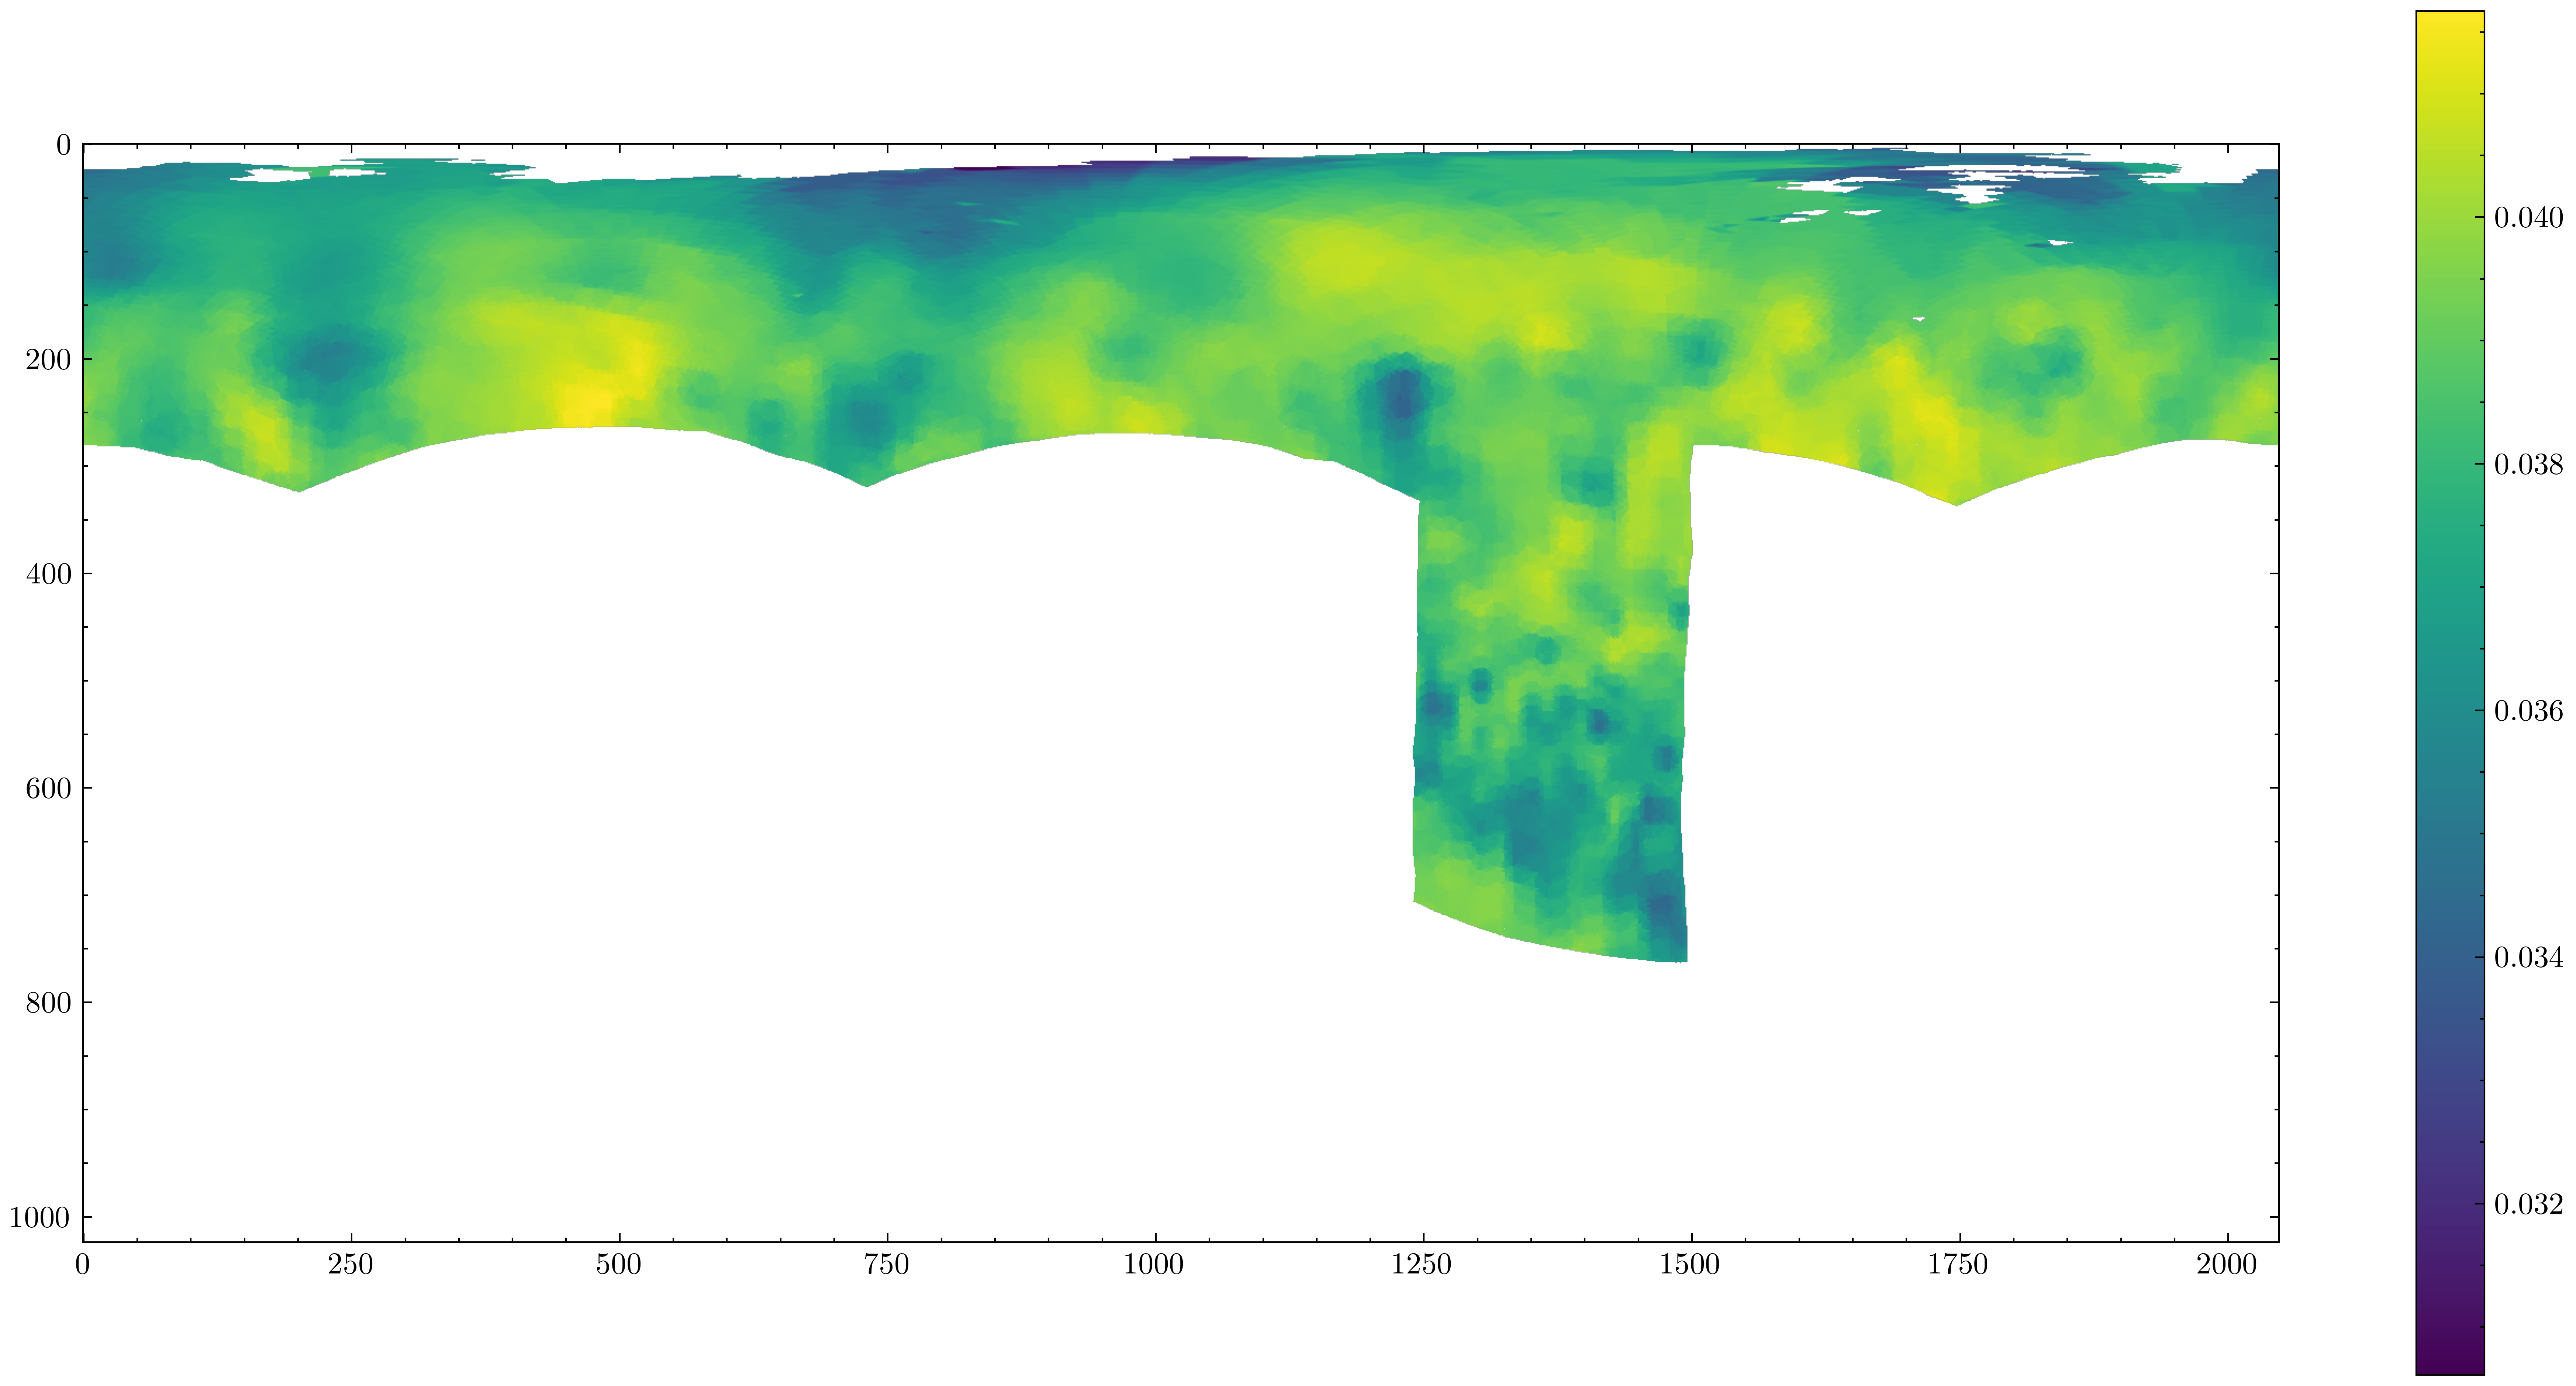

In [ ]:
from boulder_statistics.refinement_plus.inspect_tools import InspectTools

column_name = "VNIR detailed_survey Refl550nm"

pan = InspectTools.extract_column_as_equirectangular(
    df = pl.scan_parquet(pass_02_path),
    column_name=column_name,
    output_resolution=(2048, 1024)
)

plt.figure(figsize=(16, 8))
plt.imshow(pan)
plt.colorbar()
plt.show()